In [1]:
import os
import pandas as pd
import intake
import numpy as np
import xarray as xr
from easygems import healpix as egh
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import cartopy.crs as ccrs
import cartopy.feature as cf
from cartopy.util import add_cyclic_point
import colormaps as cmaps
import warnings

warnings.filterwarnings("ignore", category=FutureWarning) # don't warn us about future package conflicts
mpl.rcParams['figure.dpi'] = 150

In [2]:
source_name = "scream"
root_dir = "/pscratch/sd/w/wcmca1/hackathon/allmasks/"
in_dir = f"{root_dir}/{source_name}_allmasks_hp8_v1.zarr"

# figdir = "/global/cfs/cdirs/m1867/zfeng/hk25/quicklooks_test/"
figdir = "/pscratch/sd/w/wcmca1/hackathon/"
os.makedirs(figdir, exist_ok=True)

In [3]:
ds = xr.open_zarr(in_dir, consolidated=True)
ds = ds.pipe(egh.attach_coords)
ds

<xarray.Dataset> Size: 49GB
Dimensions:   (time: 3138, cell: 786432)
Coordinates:
  * time      (time) datetime64[ns] 25kB 2019-08-01T03:00:00 ... 2020-09-01
    crs       int64 8B 0
  * cell      (cell) int64 6MB 0 1 2 3 4 ... 786427 786428 786429 786430 786431
    lat       (cell) float64 6MB 0.1492 0.2984 0.2984 ... -0.2984 -0.1492
    lon       (cell) float64 6MB 45.0 45.18 44.82 45.0 ... 315.2 314.8 315.0
Data variables:
    ar_mask   (time, cell) int32 10GB dask.array<chunksize=(24, 786432), meta=np.ndarray>
    etc_mask  (time, cell) int32 10GB dask.array<chunksize=(24, 786432), meta=np.ndarray>
    mcs_mask  (time, cell) float64 20GB dask.array<chunksize=(24, 65536), meta=np.ndarray>
    tc_mask   (time, cell) int32 10GB dask.array<chunksize=(24, 786432), meta=np.ndarray>
Attributes: (12/37)
    Contact:                      Zhe Feng: zhe.feng@pnnl.gov
    Conventions:                  CF-1.8
    Created_on:                   Mon May  5 10:42:36 2025
    Institution:                  Pacific Northwest National Laboratory
    NCO:                          netCDF Operators version 5.3.2 (Homepage = ...
    Title:                        HEALPix remapped tracking mask data (zoom=8)
    ...                           ...
    tb_threshold_core:            225.0
    tb_threshold_environment:     261.0
    tb_threshold_warmanvil:       261.0
    topography_file:              /lustre/orion/cli115/world-shared/e3sm/inpu...
    username:                     noel
    zoom:                         8

In [4]:
# # show the map at one time step 
# def worldmap_base(title="", figsize=(10, 5)):
#     projection = ccrs.Robinson(central_longitude=-135)
#     fig, ax = plt.subplots(
#         figsize=figsize,
#         subplot_kw={"projection": projection},
#         constrained_layout=True
#     )
#     ax.set_global()
#     ax.add_feature(cf.COASTLINE, linewidth=0.8)
#     ax.add_feature(cf.BORDERS, linewidth=0.4)
#     # ax.set_extent([140, 360, -70, 70], crs=ccrs.PlateCarree())

#     # Gridlines
#     gl = ax.gridlines(draw_labels=True, linewidth=0.3, color='gray', alpha=0.5, linestyle='--')
#     gl.top_labels = False
#     gl.right_labels = False
#     gl.xlabel_style = {"size": 10}
#     gl.ylabel_style = {"size": 10}

#     ax.set_title(title, fontsize=14)

#     return fig, ax

# def overlay_mask_contour(ax, mask_da, label, color="red", alpha=1, **kwargs):
#     """
#     Overlay contour mask (on existing map).

#     Parameters:
#     - ax: The axes returned from worldmap_base
#     - mask_da: xarray DataArray (1D HEALPix or already resampled)
#     - alpha: shading transparency
#     - color: contour color
#     """
#     # Plot data=
#     # data_cyclic, lon_cyclic = add_cyclic_point(mask_da, coord=lon, axis=-1)
#     img             = egh.healpix_contour(
#         mask_da, ax=ax, level=[0.5], colors=color, linewidths=1., alpha=alpha
#     )
    
#     return img

# def overlay_mask_shading(ax, mask_da, label, cmap="tab10", alpha=0.6, **kwargs):
#     """
#     Overlay multi-category mask (e.g., 1: MCS1, 2: MCS2, 3: MCS3) on existing map.

#     Parameters:
#     - ax: The axes returned from worldmap_base
#     - mask_da: xarray DataArray (1D HEALPix or already resampled)
#     - label: string to use in legend or labeling
#     - cmap: matplotlib colormap name
#     - alpha: shading transparency
#     """

#     # Plot data
#     if label=="ARs":
#         img         = egh.healpix_show(mask_da.where(mask_da > 0), ax=ax, cmap=cmap, 
#                                    vmin=0.5, vmax=np.nanmax(mask_da)+0.5, alpha=alpha, **kwargs)
#     else:
#         img         = egh.healpix_show(mask_da, ax=ax, cmap=cmap, 
#                                    vmin=0.5, vmax=np.nanmax(mask_da)+0.5, alpha=alpha, **kwargs)
    
#     return img

In [5]:
tm = '2019-10-31T18'
temp = ds['etc_mask'].sel(time=tm).squeeze().compute()
np.unique(temp, return_counts=True)

(array([  0,  74,  97, 107], dtype=int32),
 array([693732,  45740,  41000,   5960]))

Text(0.5, 1.0, 'ETC 2019-10-31 18 UTC')

<Figure size 960x720 with 0 Axes>

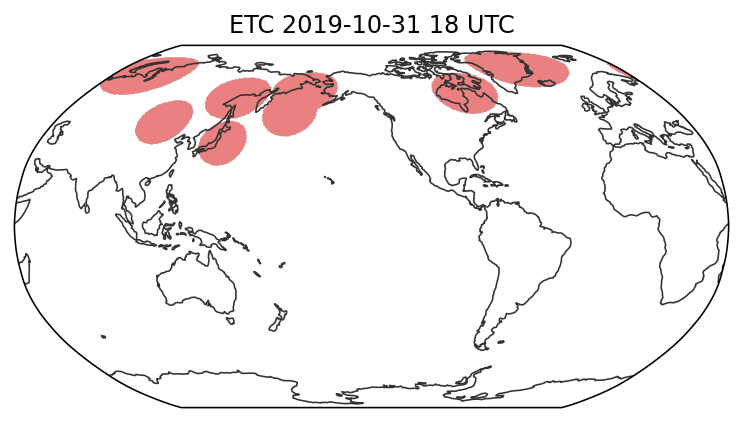

In [6]:
time_str = ds.time.sel(time=tm).dt.strftime('%Y-%m-%d %H UTC').item()
im = egh.healpix_show(temp.where(temp == 74), cmap=cmaps.cet_g_bw_minc_minl, dpi=144, alpha=0.5)
plt.title(f"ETC {time_str}")

Text(0.5, 1.0, 'AR 2019-10-31 18 UTC')

<Figure size 960x720 with 0 Axes>

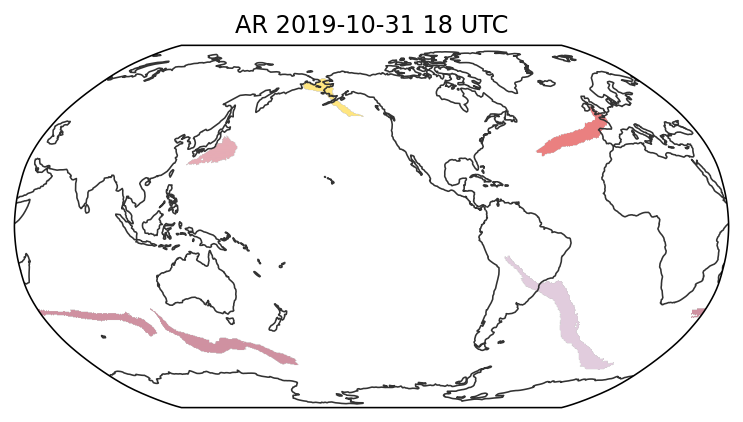

In [7]:
ar = ds['ar_mask'].sel(time=tm).squeeze().compute()
im = egh.healpix_show(ar.where(ar > 0), cmap=cmaps.cet_g_bw_minc1, dpi=144, alpha=0.5)
plt.title(f"AR {time_str}")

In [8]:
def plot_all_feature_masks(ds, title="", figsize=(12, 6), colors=None, figname=None, dpi=200, 
                          alphas=None, title_fontsize=14, legend_fontsize=12):
    """
    Plot all 4 feature masks at a single time step.
    
    Parameters:
    - ds: xarray Dataset containing the mask variables (assumes single time step)
    - title: optional title for the plot
    - figsize: figure size tuple
    - colors: dict with color names for each feature type, e.g. {'mcs': 'lightskyblue', 'ar': 'orange', 'etc': 'lightgreen', 'tc': 'lightcoral'}
    - figname: if provided, save figure as PNG with this filename
    - dpi: DPI for figure display and saving (default 200)
    - alphas: dict with alpha values for each feature type, e.g. {'mcs': 0.6, 'ar': 0.7, 'etc': 0.5, 'tc': 0.8}
    - title_fontsize: font size for the plot title (default 14)
    - legend_fontsize: font size for the legend (default 12)
    
    Returns:
    - fig, ax: matplotlib figure and axes objects
    """
    # Set default colors
    if colors is None:
        colors = {
            'mcs': 'lightskyblue',
            'ar': 'orange', 
            'etc': 'lightgreen',
            'tc': 'lightcoral'
        }
    
    # Set default alphas
    if alphas is None:
        alphas = {
            'mcs': 0.6,
            'ar': 0.6,
            'etc': 0.6,
            'tc': 0.6
        }
    
    # Create base map (integrated from worldmap_base)
    projection = ccrs.Robinson(central_longitude=-135)
    fig, ax = plt.subplots(
        figsize=figsize,
        subplot_kw={"projection": projection},
        constrained_layout=True
    )
    fig.dpi = dpi
    ax.set_global()
    ax.add_feature(cf.COASTLINE, linewidth=0.8)
    ax.add_feature(cf.BORDERS, linewidth=0.4)

    # Gridlines
    gl = ax.gridlines(draw_labels=True, linewidth=0.3, color='gray', alpha=0.5, linestyle='--')
    gl.top_labels = False
    gl.right_labels = False
    gl.xlabel_style = {"size": 10}
    gl.ylabel_style = {"size": 10}

    # Set title
    plot_title = title if title else "Feature Masks"
    ax.set_title(plot_title, fontsize=title_fontsize)
    
    # Extract masks (assuming single time step)
    mcs_mask = ds['mcs_mask'].squeeze()
    ar_mask = ds['ar_mask'].squeeze()
    etc_mask = ds['etc_mask'].squeeze()
    tc_mask = ds['tc_mask'].squeeze()
    
    # Convert masks to binary (all features = 1, no features = 0)
    mcs_binary = xr.where(mcs_mask > 0, 1, 0)
    ar_binary = xr.where(ar_mask > 0, 1, 0)
    etc_binary = xr.where(etc_mask > 0, 1, 0)
    tc_binary = xr.where(tc_mask > 0, 1, 0)
    
    # Plot MCS mask with customizable color and alpha
    if np.any(mcs_binary > 0):
        img_mcs = egh.healpix_show(
            mcs_binary.where(mcs_binary > 0), 
            ax=ax, 
            cmap=mpl.colors.ListedColormap([colors['mcs']]), 
            alpha=alphas['mcs'],
            vmin=0.5, 
            vmax=1.5
        )
    
    # Plot AR mask with customizable color and alpha
    if np.any(ar_binary > 0):
        img_ar = egh.healpix_show(
            ar_binary.where(ar_binary > 0), 
            ax=ax, 
            cmap=mpl.colors.ListedColormap([colors['ar']]), 
            alpha=alphas['ar'],
            vmin=0.5, 
            vmax=1.5
        )
    
    # Plot ETC mask with customizable color and alpha
    if np.any(etc_binary > 0):
        img_etc = egh.healpix_show(
            etc_binary.where(etc_binary > 0), 
            ax=ax, 
            cmap=mpl.colors.ListedColormap([colors['etc']]), 
            alpha=alphas['etc'],
            vmin=0.5, 
            vmax=1.5
        )
    
    # Plot TC mask with customizable color and alpha
    if np.any(tc_binary > 0):
        img_tc = egh.healpix_show(
            tc_binary.where(tc_binary > 0), 
            ax=ax, 
            cmap=mpl.colors.ListedColormap([colors['tc']]), 
            alpha=alphas['tc'],
            vmin=0.5, 
            vmax=1.5
        )
    
    # Add legend
    legend_elements = [
        Patch(facecolor=colors['mcs'], alpha=alphas['mcs'], label='MCS'),
        Patch(facecolor=colors['ar'], alpha=alphas['ar'], label='AR'),
        Patch(facecolor=colors['etc'], alpha=alphas['etc'], label='ETC'),
        Patch(facecolor=colors['tc'], alpha=alphas['tc'], label='TC')
    ]
    fig.legend(handles=legend_elements, bbox_to_anchor=(0.99, 0.99), loc='upper right', bbox_transform=fig.transFigure,
               fontsize=legend_fontsize, framealpha=0.9, fancybox=True, shadow=True)
    
    # Save figure if filename provided
    if figname is not None:
        plt.savefig(figname, dpi=dpi, bbox_inches='tight')
        print(f"Figure saved as {figname}")
    
    return fig, ax

Figure saved as /pscratch/sd/w/wcmca1/hackathon/scream_allmasks_20191124_0300.png


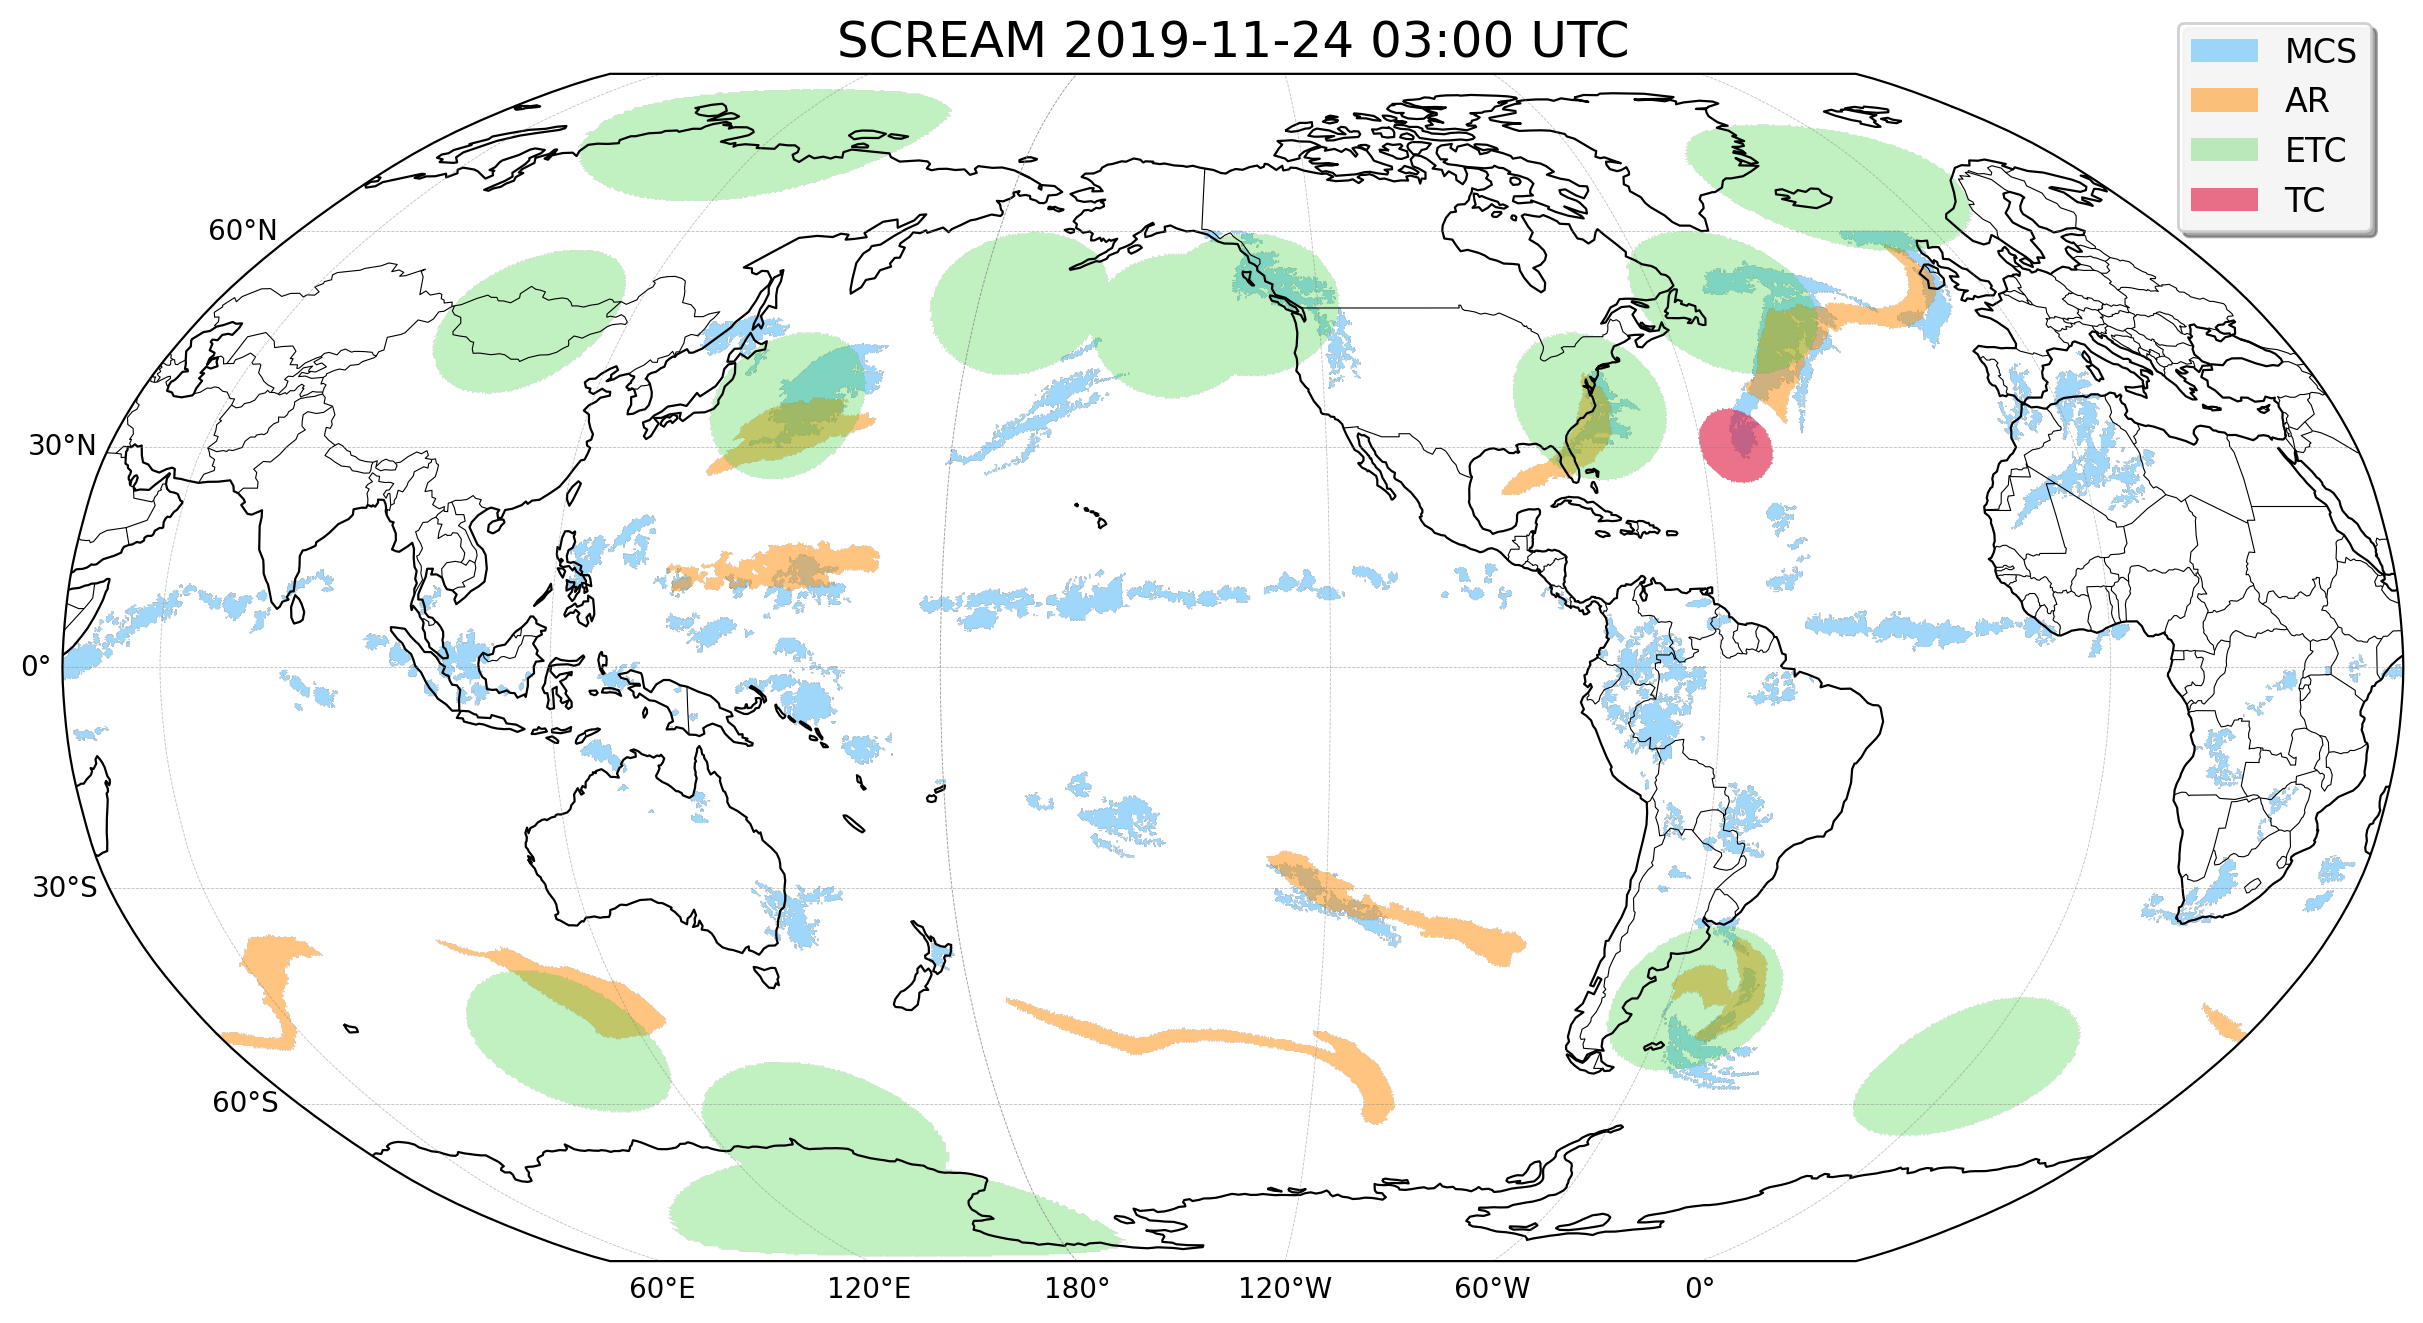

In [9]:
tm = '2019-11-24T03'
# Select single time step first
_ds = ds.sel(time=tm, method='nearest')
_time = ds.time.sel(time=tm, method='nearest')
time_label = _time.dt.strftime('%Y-%m-%d %H:%M UTC').item()
time_str = _time.dt.strftime('%Y%m%d_%H%M').item()
title_with_time = f"{source_name.upper()} {time_label}"
figname = f'{figdir}{source_name}_allmasks_{time_str}.png'

# Example with custom colors and figure saving
custom_colors = {
    'mcs': 'lightskyblue',
    'ar': 'darkorange', 
    'etc': 'limegreen',
    'tc': 'crimson'
}
# Example with custom alphas and font sizes
custom_alphas = {
    'mcs': 0.8,    # More opaque for MCS
    'ar': 0.5,     # More transparent for AR
    'etc': 0.3,    # Medium transparency for ETC
    'tc': 0.6      # Very opaque for TC
}
title_fontsize = 18
legend_fontsize = 12

fig, ax = plot_all_feature_masks(
    _ds, 
    title=title_with_time, 
    figsize=(12, 6.75),
    colors=custom_colors,
    alphas=custom_alphas,
    title_fontsize=title_fontsize,
    legend_fontsize=legend_fontsize,
    figname=figname,
    dpi=200
)
plt.show()

In [10]:
tm = '2019-11-24T03'
# Select single time step first
_ds = ds.sel(time=tm, method='nearest')

# Convert masks to binary (all features = 1, no features = 0)
mcs_binary = xr.where(_ds.mcs_mask > 0, 1, 0)
ar_binary = xr.where(_ds.ar_mask > 0, 1, 0)
etc_binary = xr.where(_ds.etc_mask > 0, 1, 0)
tc_binary = xr.where(_ds.tc_mask > 0, 1, 0)

# Sum MCS & AR binary masks, find overlaps
mcs_ar_sum = mcs_binary + ar_binary
# Create binary mask for MCS and AR co-occurrence (for visualization only)
mcs_ar_binary = xr.where(mcs_ar_sum > 1, 1, 0)

<Figure size 960x720 with 0 Axes>

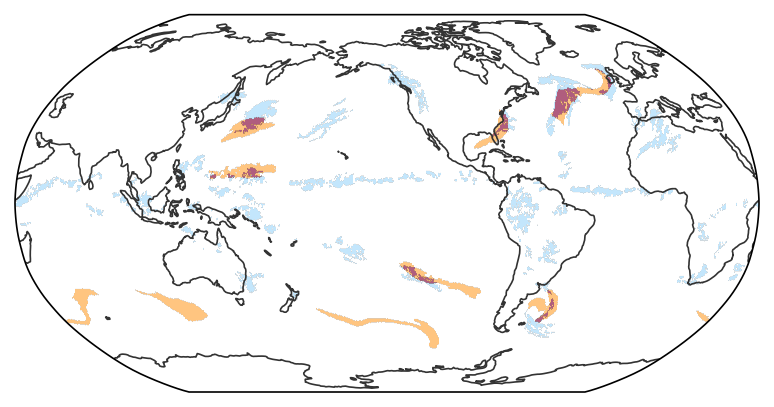

In [11]:
im1 = egh.healpix_show(mcs_binary.where(mcs_binary > 0), cmap=mpl.colors.ListedColormap('lightskyblue'), vmin=0.5, vmax=1.5, alpha=0.5)
im2 = egh.healpix_show(ar_binary.where(ar_binary > 0), cmap=mpl.colors.ListedColormap('darkorange'), vmin=0.5, vmax=1.5, alpha=0.5)

im12 = egh.healpix_show(mcs_ar_binary.where(mcs_ar_binary > 0), cmap=mpl.colors.ListedColormap('purple'), vmin=0.5, vmax=1.5, alpha=0.5)

## Function to find overlap feature numbers

In [12]:
def find_overlapping_tracks(track_mask, binary_sum_mask, min_overlap_fraction=0.2, 
                           overlap_threshold=1, verbose=False):
    """
    Find tracks that overlap with other features and exceed a minimum overlap threshold.
    
    Parameters:
    - track_mask: xarray DataArray with track IDs (e.g., MCS track numbers)
    - binary_sum_mask: xarray DataArray with sum of binary masks (overlap regions have values > threshold)
    - min_overlap_fraction: minimum fraction of track area that must overlap (default 0.2 = 20%)
    - overlap_threshold: minimum sum value to consider as overlap (default 1)
                        * 1 = any overlap (2+ features)
                        * 2 = triple overlap only (3+ features)  
                        * etc.
    - verbose: whether to print diagnostic information
    
    Returns:
    - tracks_in_overlap: array of track IDs that have any overlap
    - overlap_pixel_counts: pixel counts for each track in overlap areas
    - total_pixel_counts: total pixel counts for each track
    - overlap_fractions: fraction of each track's area that overlaps
    - tracks_exceeding_threshold: track IDs that exceed the minimum overlap fraction
    """
    
    # Step 1: Find pixels with overlap (sum > overlap_threshold)
    overlap_condition = (binary_sum_mask > overlap_threshold) & ~np.isnan(binary_sum_mask) & ~np.isnan(track_mask)
    
    # Step 2: Find track numbers within the overlap area and count pixels
    tracks_in_overlap, overlap_pixel_counts = np.unique(
        track_mask.where(overlap_condition), return_counts=True
    )
    
    # Remove NaN from results if it appears (extra safety)
    valid_mask = ~np.isnan(tracks_in_overlap)
    tracks_in_overlap = tracks_in_overlap[valid_mask]
    overlap_pixel_counts = overlap_pixel_counts[valid_mask]
    
    # Step 3: Get total pixel counts for all tracks (for fraction calculation)
    unique_tracks, total_counts = np.unique(track_mask, return_counts=True)
    track_counts_dict = dict(zip(unique_tracks, total_counts))
    
    # Extract total counts for the overlapping tracks
    total_pixel_counts = np.array([track_counts_dict.get(track, 0) for track in tracks_in_overlap])
    
    # Step 4: Compute overlap area fraction
    overlap_fractions = overlap_pixel_counts / total_pixel_counts
    
    # Step 5: Find tracks exceeding threshold
    threshold_mask = overlap_fractions > min_overlap_fraction
    tracks_exceeding_threshold = tracks_in_overlap[threshold_mask]
    
    if verbose:
        print(f"Using overlap threshold: sum > {overlap_threshold}")
        print(f"Found {len(tracks_in_overlap)} tracks with overlap")
        print(f"Overlap fractions range: {overlap_fractions.min():.3f} to {overlap_fractions.max():.3f}")
        print(f"Tracks exceeding {min_overlap_fraction:.1%} threshold: {len(tracks_exceeding_threshold)}")
        print(f"Track IDs exceeding threshold: {tracks_exceeding_threshold}")
    
    return {
        'tracks_in_overlap': tracks_in_overlap,
        'overlap_pixel_counts': overlap_pixel_counts,
        'total_pixel_counts': total_pixel_counts,
        'overlap_fractions': overlap_fractions,
        'tracks_exceeding_threshold': tracks_exceeding_threshold
    }

# Understanding Overlap Thresholds

When working with multiple binary masks, the sum tells you how many features overlap at each pixel:

## For 3 binary masks (MCS + AR + ETC):
- **Sum = 0**: No features present
- **Sum = 1**: Only 1 feature present (no overlap)
- **Sum = 2**: Exactly 2 features overlap 
- **Sum = 3**: All 3 features overlap

## Threshold Choices:
- **`binary_sum_mask > 1`**: Finds pixels with **2 or more** overlapping features (includes 2-way AND 3-way overlaps)
- **`binary_sum_mask > 2`**: Finds pixels with **3 or more** overlapping features (only 3-way overlaps)
- **`binary_sum_mask == 2`**: Finds pixels with **exactly 2** overlapping features (excludes 3-way overlaps)
- **`binary_sum_mask == 3`**: Finds pixels with **exactly 3** overlapping features (only 3-way overlaps)

## Use Cases:
- **Any overlap**: `> 1` (most common for general overlap analysis)
- **Triple overlap only**: `> 2` or `== 3` (for studying complex interactions)
- **Pairwise only**: `== 2` (for studying 2-way interactions excluding complex cases)

In [13]:
# Demonstrate different overlap thresholds with your 3-mask example
mcs_ar_etc_sum = mcs_binary + ar_binary + etc_binary

# Check what sum values exist in your data
unique_sums, sum_counts = np.unique(mcs_ar_etc_sum, return_counts=True)
print("Sum values and their pixel counts:")
for sum_val, count in zip(unique_sums, sum_counts):
    if sum_val == 0:
        print(f"  Sum = {sum_val}: {count:,} pixels (no features)")
    elif sum_val == 1:
        print(f"  Sum = {sum_val}: {count:,} pixels (1 feature only)")
    elif sum_val == 2:
        print(f"  Sum = {sum_val}: {count:,} pixels (2 features overlap)")
    elif sum_val == 3:
        print(f"  Sum = {sum_val}: {count:,} pixels (3 features overlap)")

print(f"\nTotal pixels with any overlap (sum > 1): {np.sum(sum_counts[unique_sums > 1]):,}")
print(f"Total pixels with 2-way overlap only (sum == 2): {sum_counts[unique_sums == 2][0] if 2 in unique_sums else 0:,}")
print(f"Total pixels with 3-way overlap (sum == 3): {sum_counts[unique_sums == 3][0] if 3 in unique_sums else 0:,}")

# Example: Find MCS tracks with different overlap criteria
if 3 in unique_sums:  # Only run if 3-way overlaps exist
    print("\n" + "="*50)
    print("COMPARING DIFFERENT THRESHOLDS:")
    print("="*50)
    
    # Any overlap (2 or 3 features)
    results_any = find_overlapping_tracks(
        track_mask=_ds.mcs_mask,
        binary_sum_mask=mcs_ar_etc_sum,
        min_overlap_fraction=0.1,
        verbose=False
    )
    
    # Only 3-way overlap
    results_triple = find_overlapping_tracks(
        track_mask=_ds.mcs_mask,
        binary_sum_mask=mcs_ar_etc_sum,
        min_overlap_fraction=0.1,
        verbose=False
    )
    
    print(f"MCS tracks with ANY overlap (sum > 1): {len(results_any['tracks_exceeding_threshold'])}")
    print(f"MCS tracks with 3-WAY overlap (sum > 2): {len(results_triple['tracks_exceeding_threshold'])}")
else:
    print("\nNo 3-way overlaps found in this time step.")

Sum values and their pixel counts:
  Sum = 0: 670,164 pixels (no features)
  Sum = 1: 104,375 pixels (1 feature only)
  Sum = 2: 9,654 pixels (2 features overlap)
  Sum = 3: 2,239 pixels (3 features overlap)

Total pixels with any overlap (sum > 1): 11,893
Total pixels with 2-way overlap only (sum == 2): 9,654
Total pixels with 3-way overlap (sum == 3): 2,239

COMPARING DIFFERENT THRESHOLDS:
MCS tracks with ANY overlap (sum > 1): 19
MCS tracks with 3-WAY overlap (sum > 2): 19
MCS tracks with ANY overlap (sum > 1): 19
MCS tracks with 3-WAY overlap (sum > 2): 19


In [14]:
# Sum MCS & AR binary masks, find overlaps
mcs_ar_sum = mcs_binary + ar_binary

# Set overlap thresholds
mcs_ar_thresh = 0.2
ar_mcs_thresh = 0.1

# Find MCS tracks that overlap with ARs
mcs_ar_results = find_overlapping_tracks(
    track_mask=_ds.mcs_mask,
    binary_sum_mask=mcs_ar_sum,
    overlap_threshold=1,
    min_overlap_fraction=mcs_ar_thresh,
    verbose=False
)
# Access results
mcs_tracks_with_ar_overlap = mcs_ar_results['tracks_exceeding_threshold']
print(f"\nMCS tracks with >{mcs_ar_thresh*100}% AR overlap: {mcs_tracks_with_ar_overlap}")

# AR tracks overlapping with MCS
ar_mcs_results = find_overlapping_tracks(
    track_mask=_ds.ar_mask,
    binary_sum_mask=mcs_ar_sum,
    overlap_threshold=1,
    min_overlap_fraction=ar_mcs_thresh,
    verbose=False
)
# Access results
ar_tracks_with_mcs_overlap = ar_mcs_results['tracks_exceeding_threshold']
print(f"\nAR tracks with >{ar_mcs_thresh*100}% MCS overlap: {ar_tracks_with_mcs_overlap}")


MCS tracks with >20.0% AR overlap: [15767. 15860. 15914. 15916. 15927. 15932. 15934. 15960. 15994. 15995.
 16003. 16014. 16021.]

AR tracks with >10.0% MCS overlap: [180. 182. 183. 184. 185. 186.]

AR tracks with >10.0% MCS overlap: [180. 182. 183. 184. 185. 186.]


In [15]:
# Sum MCS & ETC binary masks, find overlaps
mcs_etc_sum = mcs_binary + etc_binary

# Set overlap thresholds
mcs_etc_thresh = 0.2
etc_mcs_thresh = 0.05

# Find MCS tracks that overlap with ETCs
mcs_etc_results = find_overlapping_tracks(
    track_mask=_ds.mcs_mask,
    binary_sum_mask=mcs_etc_sum,
    overlap_threshold=1,
    min_overlap_fraction=mcs_etc_thresh,
    verbose=False
)
# Access results
mcs_tracks_with_etc_overlap = mcs_etc_results['tracks_exceeding_threshold']
print(f"\nMCS tracks with >{mcs_etc_thresh*100}% ETC overlap: {mcs_tracks_with_etc_overlap}")

# ETC tracks overlapping with MCS
etc_mcs_results = find_overlapping_tracks(
    track_mask=_ds.etc_mask,
    binary_sum_mask=mcs_etc_sum,
    overlap_threshold=1,
    min_overlap_fraction=etc_mcs_thresh,
    verbose=False
)
# Access results
etc_tracks_with_mcs_overlap = etc_mcs_results['tracks_exceeding_threshold']
print(f"\nETC tracks with >{etc_mcs_thresh*100}% MCS overlap: {etc_tracks_with_mcs_overlap}")


MCS tracks with >20.0% ETC overlap: [15767. 15818. 15914. 15916. 15932. 15957. 15980. 15994. 15995. 16001.
 16003. 16011. 16014.]

ETC tracks with >5.0% MCS overlap: [129. 132. 133. 135. 137.]


MCS tracks in overlap mask: [15767. 15860. 15914. 15916. 15927. 15932. 15934. 15960. 15994. 15995.
 16003. 16014. 16021.]
AR tracks in overlap mask: [180 182 183 184 185 186]


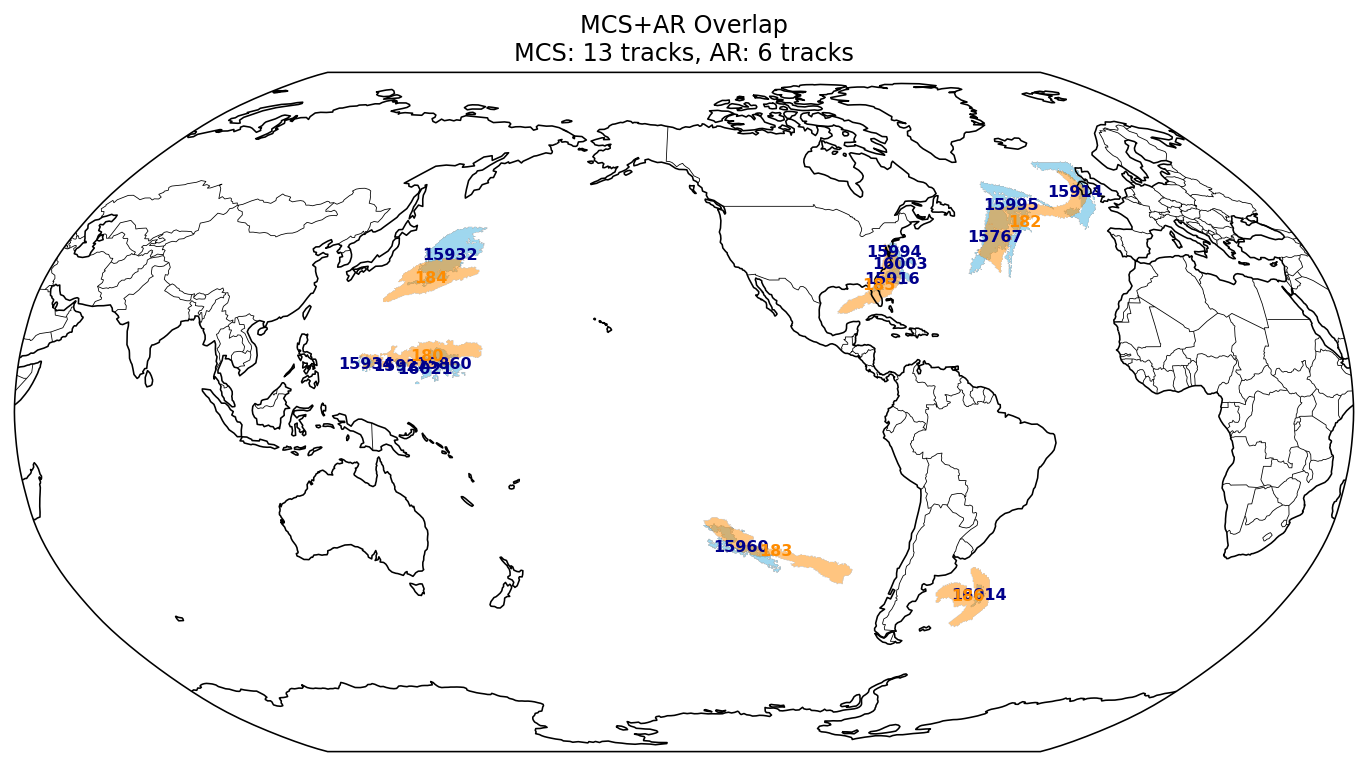

In [16]:
# Create a new mask array with only MCS tracks that have significant AR overlap
mcs_ar_overlap_mask = xr.where(
    _ds.mcs_mask.isin(mcs_tracks_with_ar_overlap), 
    _ds.mcs_mask, 
    0
)
# Display info about the new mask
print(f"MCS tracks in overlap mask: {np.unique(mcs_ar_overlap_mask)[np.unique(mcs_ar_overlap_mask) > 0]}")

ar_mcs_overlap_mask = xr.where(
    _ds.ar_mask.isin(ar_tracks_with_mcs_overlap), 
    _ds.ar_mask, 
    0
)
print(f"AR tracks in overlap mask: {np.unique(ar_mcs_overlap_mask)[np.unique(ar_mcs_overlap_mask) > 0]}")

# Create figure with proper projection
projection = ccrs.Robinson(central_longitude=-135)
fig, ax = plt.subplots(figsize=(12, 8), subplot_kw={"projection": projection})
ax.set_global()
ax.add_feature(cf.COASTLINE, linewidth=0.8)
ax.add_feature(cf.BORDERS, linewidth=0.4)

# Visualize the new mask
im_overlap = egh.healpix_show(
    mcs_ar_overlap_mask.where(mcs_ar_overlap_mask > 0), 
    # cmap=cmaps.cet_g_bw_minc_minl, 
    cmap=mpl.colors.ListedColormap('skyblue'),
    dpi=144, 
    alpha=0.8,
    ax=ax
)
im_overlap = egh.healpix_show(
    ar_mcs_overlap_mask.where(ar_mcs_overlap_mask > 0), 
    cmap=mpl.colors.ListedColormap('darkorange'), 
    dpi=144, 
    alpha=0.5,
    ax=ax
)
fontsize_tracks = 8

# Add track number annotations
# For MCS tracks
for track_id in mcs_tracks_with_ar_overlap:
    # Find pixels belonging to this track
    track_pixels = _ds.mcs_mask == track_id
    if track_pixels.any():
        # Calculate average lat/lon for this track (compute dask arrays first)
        avg_lon = _ds.lon.where(track_pixels).mean().compute().item()
        avg_lat = _ds.lat.where(track_pixels).mean().compute().item()
        
        # Add text annotation with darker blue color
        ax.text(avg_lon, avg_lat, str(int(track_id)), 
                transform=ccrs.PlateCarree(),
                fontsize=fontsize_tracks, fontweight='bold',
                color='darkblue',
                ha='center', va='center',
                # bbox=dict(boxstyle="round,pad=0.2", facecolor='white', alpha=0.7, edgecolor='none'))
        )

# For AR tracks  
for track_id in ar_tracks_with_mcs_overlap:
    # Find pixels belonging to this track
    track_pixels = _ds.ar_mask == track_id
    if track_pixels.any():
        # Calculate average lat/lon for this track (compute dask arrays first)
        avg_lon = _ds.lon.where(track_pixels).mean().compute().item()
        avg_lat = _ds.lat.where(track_pixels).mean().compute().item()
        
        # Add text annotation with darker orange color
        ax.text(avg_lon, avg_lat, str(int(track_id)), 
                transform=ccrs.PlateCarree(),
                fontsize=fontsize_tracks, fontweight='bold',
                color='darkorange',
                ha='center', va='center',
                # bbox=dict(boxstyle="round,pad=0.2", facecolor='white', alpha=0.7, edgecolor='none'))
        )

ax.set_title(f"MCS+AR Overlap\nMCS: {len(mcs_tracks_with_ar_overlap)} tracks, AR: {len(ar_tracks_with_mcs_overlap)} tracks")
plt.show()

MCS tracks in overlap mask: [15767. 15818. 15914. 15916. 15932. 15957. 15980. 15994. 15995. 16001.
 16003. 16011. 16014.]
ETC tracks in overlap mask: [129 132 133 135 137]


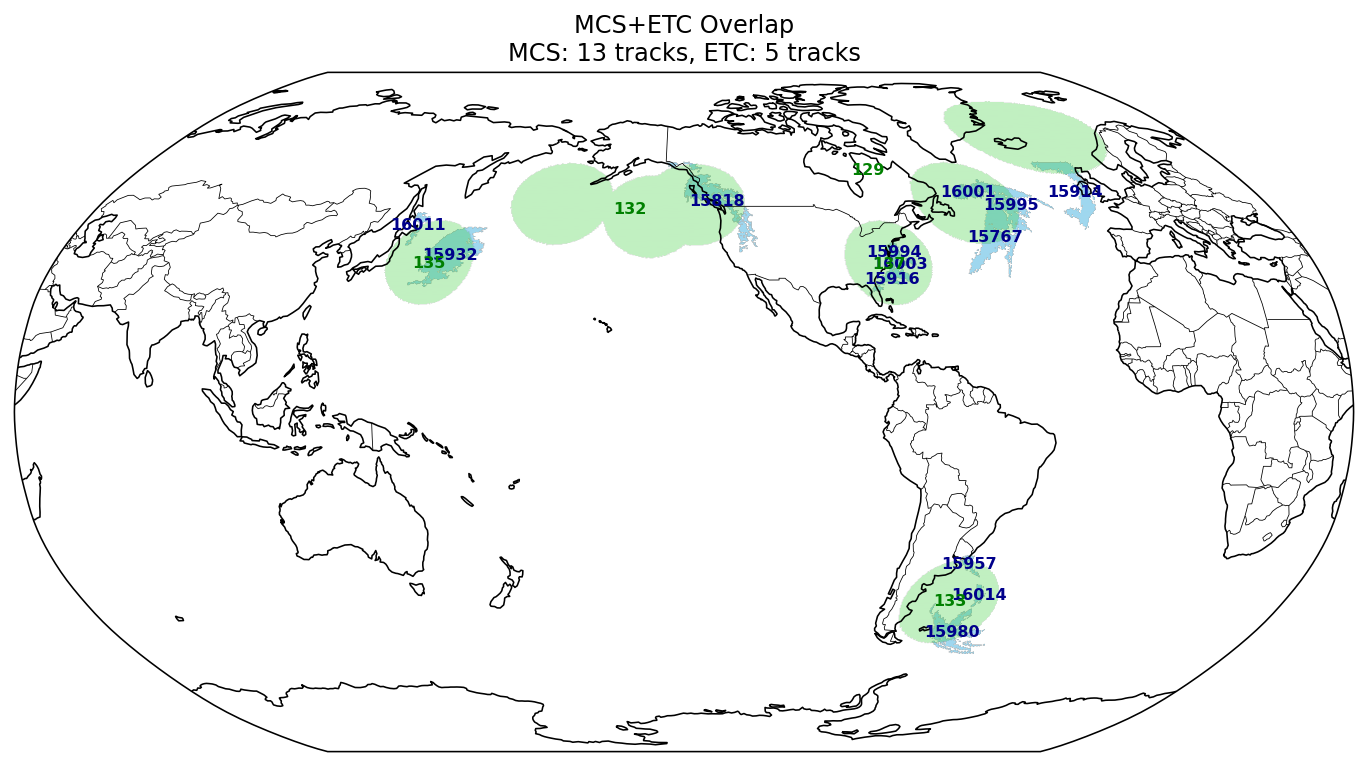

In [27]:
# Create a new mask array with only MCS tracks that have significant ETC overlap
mcs_etc_overlap_mask = xr.where(
    _ds.mcs_mask.isin(mcs_tracks_with_etc_overlap), 
    _ds.mcs_mask, 
    0
)
# Display info about the new mask
print(f"MCS tracks in overlap mask: {np.unique(mcs_etc_overlap_mask)[np.unique(mcs_etc_overlap_mask) > 0]}")

# Create a new mask array with only ETC tracks that have significant MCS overlap
etc_mcs_overlap_mask = xr.where(
    _ds.etc_mask.isin(etc_tracks_with_mcs_overlap), 
    _ds.etc_mask, 
    0
)
print(f"ETC tracks in overlap mask: {np.unique(etc_mcs_overlap_mask)[np.unique(etc_mcs_overlap_mask) > 0]}")

# Create figure with proper projection
projection = ccrs.Robinson(central_longitude=-135)
fig, ax = plt.subplots(figsize=(12, 8), subplot_kw={"projection": projection})
ax.set_global()
ax.add_feature(cf.COASTLINE, linewidth=0.8)
ax.add_feature(cf.BORDERS, linewidth=0.4)

# Visualize the new mask
im_overlap = egh.healpix_show(
    mcs_etc_overlap_mask.where(mcs_etc_overlap_mask > 0), 
    cmap=mpl.colors.ListedColormap('skyblue'),
    dpi=144, 
    alpha=0.8,
    ax=ax
)
im_overlap = egh.healpix_show(
    etc_mcs_overlap_mask.where(etc_mcs_overlap_mask > 0), 
    cmap=mpl.colors.ListedColormap('limegreen'), 
    dpi=144, 
    alpha=0.3,
    ax=ax
)
fontsize_tracks = 8

# Add track number annotations
# For MCS tracks
for track_id in mcs_tracks_with_etc_overlap:
    # Find pixels belonging to this track
    track_pixels = _ds.mcs_mask == track_id
    if track_pixels.any():
        # Calculate average lat/lon for this track (compute dask arrays first)
        avg_lon = _ds.lon.where(track_pixels).mean().compute().item()
        avg_lat = _ds.lat.where(track_pixels).mean().compute().item()
        
        # Add text annotation with darker blue color
        ax.text(avg_lon, avg_lat, str(int(track_id)), 
                transform=ccrs.PlateCarree(),
                fontsize=fontsize_tracks, fontweight='bold',
                color='darkblue',
                ha='center', va='center',
                # bbox=dict(boxstyle="round,pad=0.2", facecolor='white', alpha=0.7, edgecolor='none'))
        )

# For ETC tracks  
for track_id in etc_tracks_with_mcs_overlap:
    # Find pixels belonging to this track
    track_pixels = _ds.etc_mask == track_id
    if track_pixels.any():
        # Calculate average lat/lon for this track (compute dask arrays first)
        avg_lon = _ds.lon.where(track_pixels).mean().compute().item()
        avg_lat = _ds.lat.where(track_pixels).mean().compute().item()
        
        # Add text annotation with darker orange color
        ax.text(avg_lon, avg_lat, str(int(track_id)), 
                transform=ccrs.PlateCarree(),
                fontsize=fontsize_tracks, fontweight='bold',
                color='green',
                ha='center', va='center',
                # bbox=dict(boxstyle="round,pad=0.2", facecolor='white', alpha=0.7, edgecolor='none'))
        )

ax.set_title(f"MCS+ETC Overlap\nMCS: {len(mcs_tracks_with_etc_overlap)} tracks, ETC: {len(etc_tracks_with_mcs_overlap)} tracks")
plt.show()

In [19]:
# Sum MCS & AR binary masks, find overlaps
mcs_ar_etc_sum = mcs_binary + ar_binary + etc_binary

# Set overlap thresholds
mcs_ar_etc_thresh = 0.2
ar_mcs_etc_thresh = 0.1
etc_mcs_ar_thresh = 0.05

# MCS tracks that overlap with AR & ETC
mcs_ar_etc_results = find_overlapping_tracks(
    track_mask=_ds.mcs_mask,
    binary_sum_mask=mcs_ar_etc_sum,
    overlap_threshold=2,
    min_overlap_fraction=mcs_ar_etc_thresh,
    verbose=False
)
# Access results
mcs_tracks_with_ar_etc_overlap = mcs_ar_etc_results['tracks_exceeding_threshold']
print(f"\nMCS tracks with >{mcs_ar_etc_thresh*100}% AR+ETC overlap: {mcs_tracks_with_ar_etc_overlap}")

# AR tracks overlapping with MCS & ETC
ar_mcs_etc_results = find_overlapping_tracks(
    track_mask=_ds.ar_mask,
    binary_sum_mask=mcs_ar_etc_sum,
    overlap_threshold=2,
    min_overlap_fraction=ar_mcs_etc_thresh,
    verbose=False
)
# Access results
ar_tracks_with_mcs_etc_overlap = ar_mcs_etc_results['tracks_exceeding_threshold']
print(f"\nAR tracks with >{ar_mcs_etc_thresh*100}% MCS+ETC overlap: {ar_tracks_with_mcs_etc_overlap}")

# ETC tracks overlapping with MCS & AR
etc_mcs_ar_results = find_overlapping_tracks(
    track_mask=_ds.etc_mask,
    binary_sum_mask=mcs_ar_etc_sum,
    overlap_threshold=2,
    min_overlap_fraction=etc_mcs_ar_thresh,
    verbose=False
)
# Access results
etc_tracks_with_mcs_ar_overlap = etc_mcs_ar_results['tracks_exceeding_threshold']
print(f"\nETC tracks with >{etc_mcs_ar_thresh*100}% MCS+AR overlap: {etc_tracks_with_mcs_ar_overlap}")


MCS tracks with >20.0% AR+ETC overlap: [15767. 15916. 15932. 15994. 15995. 16003. 16014.]

AR tracks with >10.0% MCS+ETC overlap: [182. 184. 185. 186.]

ETC tracks with >5.0% MCS+AR overlap: [129. 135. 137.]

ETC tracks with >5.0% MCS+AR overlap: [129. 135. 137.]


In [20]:
# Remove tracks from 2-feature overlap lists if they are also in 3-feature overlap lists
# This ensures distinct categories: 2-way only vs 3-way overlap

print("BEFORE filtering:")
print(f"MCS tracks with AR overlap (2-way): {len(mcs_tracks_with_ar_overlap)}")
print(f"MCS tracks with ETC overlap (2-way): {len(mcs_tracks_with_etc_overlap)}")
print(f"MCS tracks with AR+ETC overlap (3-way): {len(mcs_tracks_with_ar_etc_overlap)}")
print(f"AR tracks with MCS overlap (2-way): {len(ar_tracks_with_mcs_overlap)}")
print(f"ETC tracks with MCS overlap (2-way): {len(etc_tracks_with_mcs_overlap)}")
print(f"AR tracks with MCS+ETC overlap (3-way): {len(ar_tracks_with_mcs_etc_overlap)}")
print(f"ETC tracks with MCS+AR overlap (3-way): {len(etc_tracks_with_mcs_ar_overlap)}")

# Filter MCS tracks: remove 3-way overlap tracks from 2-way overlap lists
mcs_tracks_with_ar_overlap_only = np.setdiff1d(mcs_tracks_with_ar_overlap, mcs_tracks_with_ar_etc_overlap)
mcs_tracks_with_etc_overlap_only = np.setdiff1d(mcs_tracks_with_etc_overlap, mcs_tracks_with_ar_etc_overlap)

# Filter AR tracks: remove 3-way overlap tracks from 2-way overlap list  
ar_tracks_with_mcs_overlap_only = np.setdiff1d(ar_tracks_with_mcs_overlap, ar_tracks_with_mcs_etc_overlap)

# Filter ETC tracks: remove 3-way overlap tracks from 2-way overlap list
etc_tracks_with_mcs_overlap_only = np.setdiff1d(etc_tracks_with_mcs_overlap, etc_tracks_with_mcs_ar_overlap)

print("\nAFTER filtering:")
print(f"MCS tracks with AR overlap ONLY (2-way exclusive): {len(mcs_tracks_with_ar_overlap_only)}")
print(f"MCS tracks with ETC overlap ONLY (2-way exclusive): {len(mcs_tracks_with_etc_overlap_only)}")
print(f"MCS tracks with AR+ETC overlap (3-way): {len(mcs_tracks_with_ar_etc_overlap)}")
print(f"AR tracks with MCS overlap ONLY (2-way exclusive): {len(ar_tracks_with_mcs_overlap_only)}")
print(f"ETC tracks with MCS overlap ONLY (2-way exclusive): {len(etc_tracks_with_mcs_overlap_only)}")
print(f"AR tracks with MCS+ETC overlap (3-way): {len(ar_tracks_with_mcs_etc_overlap)}")
print(f"ETC tracks with MCS+AR overlap (3-way): {len(etc_tracks_with_mcs_ar_overlap)}")

print("\nTrack ID details:")
print(f"MCS-AR 2-way only: {mcs_tracks_with_ar_overlap_only}")
print(f"MCS-ETC 2-way only: {mcs_tracks_with_etc_overlap_only}")
print(f"MCS 3-way: {mcs_tracks_with_ar_etc_overlap}")
print(f"AR 2-way only: {ar_tracks_with_mcs_overlap_only}")
print(f"ETC 2-way only: {etc_tracks_with_mcs_overlap_only}")
print(f"AR 3-way: {ar_tracks_with_mcs_etc_overlap}")
print(f"ETC 3-way: {etc_tracks_with_mcs_ar_overlap}")

# Check for any overlap between the filtered lists (should be empty)
mcs_ar_overlap_check = np.intersect1d(mcs_tracks_with_ar_overlap_only, mcs_tracks_with_ar_etc_overlap)
mcs_etc_overlap_check = np.intersect1d(mcs_tracks_with_etc_overlap_only, mcs_tracks_with_ar_etc_overlap)
ar_overlap_check = np.intersect1d(ar_tracks_with_mcs_overlap_only, ar_tracks_with_mcs_etc_overlap)
etc_overlap_check = np.intersect1d(etc_tracks_with_mcs_overlap_only, etc_tracks_with_mcs_ar_overlap)

print(f"\nVerification (should be empty arrays):")
print(f"MCS tracks in both MCS-AR 2-way and 3-way lists: {mcs_ar_overlap_check}")
print(f"MCS tracks in both MCS-ETC 2-way and 3-way lists: {mcs_etc_overlap_check}")
print(f"AR tracks in both 2-way and 3-way lists: {ar_overlap_check}")
print(f"ETC tracks in both 2-way and 3-way lists: {etc_overlap_check}")

# Additional check: ensure no MCS track appears in both 2-way overlap categories
mcs_2way_overlap_check = np.intersect1d(mcs_tracks_with_ar_overlap_only, mcs_tracks_with_etc_overlap_only)
print(f"MCS tracks in both MCS-AR and MCS-ETC 2-way lists: {mcs_2way_overlap_check}")
print(f"(This can be non-empty - tracks can overlap with AR in some areas and ETC in others)")

BEFORE filtering:
MCS tracks with AR overlap (2-way): 13
MCS tracks with ETC overlap (2-way): 13
MCS tracks with AR+ETC overlap (3-way): 7
AR tracks with MCS overlap (2-way): 6
ETC tracks with MCS overlap (2-way): 5
AR tracks with MCS+ETC overlap (3-way): 4
ETC tracks with MCS+AR overlap (3-way): 3

AFTER filtering:
MCS tracks with AR overlap ONLY (2-way exclusive): 6
MCS tracks with ETC overlap ONLY (2-way exclusive): 6
MCS tracks with AR+ETC overlap (3-way): 7
AR tracks with MCS overlap ONLY (2-way exclusive): 2
ETC tracks with MCS overlap ONLY (2-way exclusive): 2
AR tracks with MCS+ETC overlap (3-way): 4
ETC tracks with MCS+AR overlap (3-way): 3

Track ID details:
MCS-AR 2-way only: [15860. 15914. 15927. 15934. 15960. 16021.]
MCS-ETC 2-way only: [15818. 15914. 15957. 15980. 16001. 16011.]
MCS 3-way: [15767. 15916. 15932. 15994. 15995. 16003. 16014.]
AR 2-way only: [180. 183.]
ETC 2-way only: [132. 133.]
AR 3-way: [182. 184. 185. 186.]
ETC 3-way: [129. 135. 137.]

Verification (shou

Creating distinct overlap masks...
Mask creation complete!

Distinct overlap categories:
MCS tracks in 2-way overlap only: 6
MCS tracks in 3-way overlap: 7
AR tracks in 2-way overlap only: 2
AR tracks in 3-way overlap: 4
AR tracks in 2-way overlap only: 2
AR tracks in 3-way overlap: 4
ETC tracks in 3-way overlap: 3
ETC tracks in 3-way overlap: 3


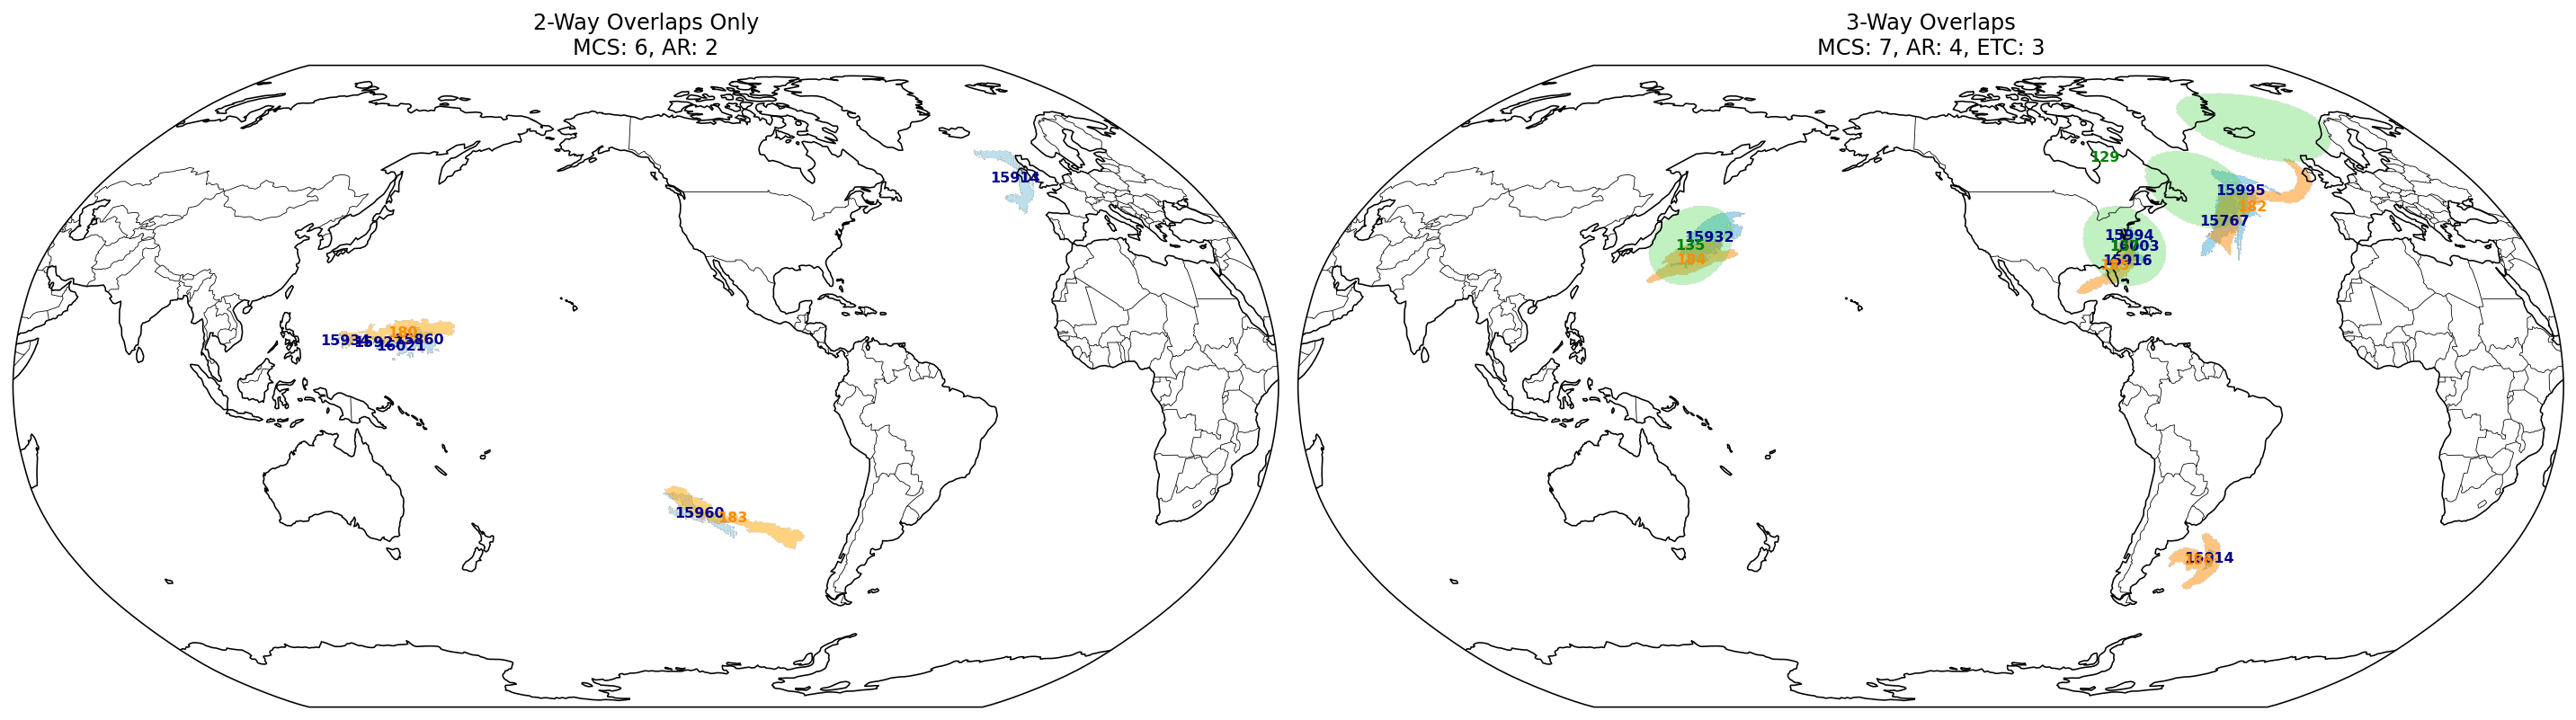

In [22]:
# Create distinct masks for 2-way vs 3-way overlaps
print("Creating distinct overlap masks...")

# 2-way overlap masks (exclusive - no 3-way overlap tracks)
mcs_ar_overlap_mask_only = xr.where(
    _ds.mcs_mask.isin(mcs_tracks_with_ar_overlap_only), 
    _ds.mcs_mask, 
    0
)

ar_mcs_overlap_mask_only = xr.where(
    _ds.ar_mask.isin(ar_tracks_with_mcs_overlap_only), 
    _ds.ar_mask, 
    0
)

# 3-way overlap masks (already created but for reference)
mcs_ar_etc_overlap_mask = xr.where(
    _ds.mcs_mask.isin(mcs_tracks_with_ar_etc_overlap), 
    _ds.mcs_mask, 
    0
)

ar_mcs_etc_overlap_mask = xr.where(
    _ds.ar_mask.isin(ar_tracks_with_mcs_etc_overlap), 
    _ds.ar_mask, 
    0
)

etc_mcs_ar_overlap_mask = xr.where(
    _ds.etc_mask.isin(etc_tracks_with_mcs_ar_overlap), 
    _ds.etc_mask, 
    0
)

print("Mask creation complete!")

# Display track counts in each category
print(f"\nDistinct overlap categories:")
print(f"MCS tracks in 2-way overlap only: {len(np.unique(mcs_ar_overlap_mask_only)[np.unique(mcs_ar_overlap_mask_only) > 0])}")
print(f"MCS tracks in 3-way overlap: {len(np.unique(mcs_ar_etc_overlap_mask)[np.unique(mcs_ar_etc_overlap_mask) > 0])}")
print(f"AR tracks in 2-way overlap only: {len(np.unique(ar_mcs_overlap_mask_only)[np.unique(ar_mcs_overlap_mask_only) > 0])}")
print(f"AR tracks in 3-way overlap: {len(np.unique(ar_mcs_etc_overlap_mask)[np.unique(ar_mcs_etc_overlap_mask) > 0])}")
print(f"ETC tracks in 3-way overlap: {len(np.unique(etc_mcs_ar_overlap_mask)[np.unique(etc_mcs_ar_overlap_mask) > 0])}")

# Visualize distinct overlap categories with proper projection
projection = ccrs.Robinson(central_longitude=-135)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 8), 
                               subplot_kw={"projection": projection})

# Add coastlines and features to both axes
for ax in [ax1, ax2]:
    ax.set_global()
    ax.add_feature(cf.COASTLINE, linewidth=0.8)
    ax.add_feature(cf.BORDERS, linewidth=0.4)

fontsize_tracks = 8

# Plot 1: 2-way overlaps only
plt.sca(ax1)

im_mcs_2way = egh.healpix_show(
    mcs_ar_overlap_mask_only.where(mcs_ar_overlap_mask_only > 0), 
    cmap=mpl.colors.ListedColormap('lightblue'),
    dpi=144, 
    alpha=0.8,
    ax=ax1,
)
im_ar_2way = egh.healpix_show(
    ar_mcs_overlap_mask_only.where(ar_mcs_overlap_mask_only > 0), 
    cmap=mpl.colors.ListedColormap('orange'), 
    dpi=144, 
    alpha=0.5,
    ax=ax1,
)

# Add track number annotations for 2-way overlaps
# For MCS tracks (2-way only)
for track_id in mcs_tracks_with_ar_overlap_only:
    track_pixels = _ds.mcs_mask == track_id
    if track_pixels.any():
        avg_lon = _ds.lon.where(track_pixels).mean().compute().item()
        avg_lat = _ds.lat.where(track_pixels).mean().compute().item()
        ax1.text(avg_lon, avg_lat, str(int(track_id)), 
                transform=ccrs.PlateCarree(),
                fontsize=fontsize_tracks, fontweight='bold',
                color='darkblue',
                ha='center', va='center')

# For AR tracks (2-way only)
for track_id in ar_tracks_with_mcs_overlap_only:
    track_pixels = _ds.ar_mask == track_id
    if track_pixels.any():
        avg_lon = _ds.lon.where(track_pixels).mean().compute().item()
        avg_lat = _ds.lat.where(track_pixels).mean().compute().item()
        ax1.text(avg_lon, avg_lat, str(int(track_id)), 
                transform=ccrs.PlateCarree(),
                fontsize=fontsize_tracks, fontweight='bold',
                color='darkorange',
                ha='center', va='center')

ax1.set_title(f"2-Way Overlaps Only\nMCS: {len(mcs_tracks_with_ar_overlap_only)}, AR: {len(ar_tracks_with_mcs_overlap_only)}")

# Plot 2: 3-way overlaps
plt.sca(ax2)
im_mcs_3way = egh.healpix_show(
    mcs_ar_etc_overlap_mask.where(mcs_ar_etc_overlap_mask > 0), 
    cmap=mpl.colors.ListedColormap('skyblue'),
    dpi=144, 
    alpha=0.8,
    ax=ax2,
)
im_ar_3way = egh.healpix_show(
    ar_mcs_etc_overlap_mask.where(ar_mcs_etc_overlap_mask > 0), 
    cmap=mpl.colors.ListedColormap('darkorange'), 
    dpi=144, 
    alpha=0.5,
    ax=ax2,
)
im_etc_3way = egh.healpix_show(
    etc_mcs_ar_overlap_mask.where(etc_mcs_ar_overlap_mask > 0),
    cmap=mpl.colors.ListedColormap('limegreen'),
    dpi=144,
    alpha=0.3,
    ax=ax2,
)

# Add track number annotations for 3-way overlaps
# For MCS tracks (3-way)
for track_id in mcs_tracks_with_ar_etc_overlap:
    track_pixels = _ds.mcs_mask == track_id
    if track_pixels.any():
        avg_lon = _ds.lon.where(track_pixels).mean().compute().item()
        avg_lat = _ds.lat.where(track_pixels).mean().compute().item()
        ax2.text(avg_lon, avg_lat, str(int(track_id)), 
                transform=ccrs.PlateCarree(),
                fontsize=fontsize_tracks, fontweight='bold',
                color='darkblue',
                ha='center', va='center')

# For AR tracks (3-way)
for track_id in ar_tracks_with_mcs_etc_overlap:
    track_pixels = _ds.ar_mask == track_id
    if track_pixels.any():
        avg_lon = _ds.lon.where(track_pixels).mean().compute().item()
        avg_lat = _ds.lat.where(track_pixels).mean().compute().item()
        ax2.text(avg_lon, avg_lat, str(int(track_id)), 
                transform=ccrs.PlateCarree(),
                fontsize=fontsize_tracks, fontweight='bold',
                color='darkorange',
                ha='center', va='center')

# For ETC tracks (3-way)
for track_id in etc_tracks_with_mcs_ar_overlap:
    track_pixels = _ds.etc_mask == track_id
    if track_pixels.any():
        avg_lon = _ds.lon.where(track_pixels).mean().compute().item()
        avg_lat = _ds.lat.where(track_pixels).mean().compute().item()
        ax2.text(avg_lon, avg_lat, str(int(track_id)), 
                transform=ccrs.PlateCarree(),
                fontsize=fontsize_tracks, fontweight='bold',
                color='green',
                ha='center', va='center')

ax2.set_title(f"3-Way Overlaps\nMCS: {len(mcs_tracks_with_ar_etc_overlap)}, AR: {len(ar_tracks_with_mcs_etc_overlap)}, ETC: {len(etc_tracks_with_mcs_ar_overlap)}")

plt.tight_layout()
plt.show()

In [26]:
# Demonstrate the logical inconsistency you identified
print("DEMONSTRATING THE LOGICAL INCONSISTENCY:")
print("="*60)

# Let's check the specific case you mentioned
mcs_track_15914_in_2way = 15914 in mcs_tracks_with_ar_overlap_only
ar_track_182_in_2way = 182 in ar_tracks_with_mcs_overlap_only
ar_track_182_in_3way = 182 in ar_tracks_with_mcs_etc_overlap

print(f"MCS track 15914 in 2-way overlap list: {mcs_track_15914_in_2way}")
print(f"AR track 182 in 2-way overlap list: {ar_track_182_in_2way}")
print(f"AR track 182 in 3-way overlap list: {ar_track_182_in_3way}")

if mcs_track_15914_in_2way and not ar_track_182_in_2way:
    print("\n⚠️  INCONSISTENCY DETECTED:")
    print("   - MCS 15914 appears in 2-way map (has AR overlap)")
    print("   - But its overlapping AR 182 does NOT appear in 2-way map")
    print("   - This creates 'orphaned' tracks with no visible overlap partner")

# Check for more general cases of this problem
print(f"\n{'SYSTEMATIC ANALYSIS:'}")
print("="*40)

# Find all MCS tracks in 2-way that overlap with ARs not in 2-way list
orphaned_mcs_tracks = []
for mcs_track in mcs_tracks_with_ar_overlap_only:
    # Find which AR tracks this MCS overlaps with
    mcs_pixels = _ds.mcs_mask == mcs_track
    mcs_ar_overlap_pixels = (mcs_ar_sum > 1) & mcs_pixels
    
    if mcs_ar_overlap_pixels.any():
        # Get AR tracks in the overlap region
        overlapping_ar_tracks = np.unique(_ds.ar_mask.where(mcs_ar_overlap_pixels))
        overlapping_ar_tracks = overlapping_ar_tracks[~np.isnan(overlapping_ar_tracks)]
        
        # Check if any of these AR tracks are NOT in the 2-way list
        for ar_track in overlapping_ar_tracks:
            if ar_track not in ar_tracks_with_mcs_overlap_only:
                orphaned_mcs_tracks.append((mcs_track, ar_track))
                
print(f"Orphaned MCS tracks (appear in 2-way but partner AR is in 3-way): {len(orphaned_mcs_tracks)}")
for mcs_track, ar_track in orphaned_mcs_tracks[:5]:  # Show first 5 examples
    print(f"  MCS {mcs_track} overlaps with AR {ar_track} (AR is in 3-way list)")

# Similarly check for orphaned AR tracks
orphaned_ar_tracks = []
for ar_track in ar_tracks_with_mcs_overlap_only:
    # Find which MCS tracks this AR overlaps with
    ar_pixels = _ds.ar_mask == ar_track
    ar_mcs_overlap_pixels = (mcs_ar_sum > 1) & ar_pixels
    
    if ar_mcs_overlap_pixels.any():
        # Get MCS tracks in the overlap region
        overlapping_mcs_tracks = np.unique(_ds.mcs_mask.where(ar_mcs_overlap_pixels))
        overlapping_mcs_tracks = overlapping_mcs_tracks[~np.isnan(overlapping_mcs_tracks)]
        
        # Check if any of these MCS tracks are NOT in the 2-way list
        for mcs_track in overlapping_mcs_tracks:
            if mcs_track not in mcs_tracks_with_ar_overlap_only:
                orphaned_ar_tracks.append((ar_track, mcs_track))

print(f"Orphaned AR tracks (appear in 2-way but partner MCS is in 3-way): {len(orphaned_ar_tracks)}")
for ar_track, mcs_track in orphaned_ar_tracks[:5]:  # Show first 5 examples
    print(f"  AR {ar_track} overlaps with MCS {mcs_track} (MCS is in 3-way list)")

print(f"\n{'PROPOSED SOLUTION:'}")
print("="*30)
print("Instead of filtering individual tracks, we should:")
print("1. Identify track PAIRS for 2-way overlaps")
print("2. Remove entire PAIRS if either track participates in 3-way overlaps")
print("3. This ensures visual consistency - no orphaned tracks")

DEMONSTRATING THE LOGICAL INCONSISTENCY:
MCS track 15914 in 2-way overlap list: True
AR track 182 in 2-way overlap list: False
AR track 182 in 3-way overlap list: True

⚠️  INCONSISTENCY DETECTED:
   - MCS 15914 appears in 2-way map (has AR overlap)
   - But its overlapping AR 182 does NOT appear in 2-way map
   - This creates 'orphaned' tracks with no visible overlap partner

SYSTEMATIC ANALYSIS:
Orphaned MCS tracks (appear in 2-way but partner AR is in 3-way): 1
  MCS 15914.0 overlaps with AR 182.0 (AR is in 3-way list)
Orphaned MCS tracks (appear in 2-way but partner AR is in 3-way): 1
  MCS 15914.0 overlaps with AR 182.0 (AR is in 3-way list)
Orphaned AR tracks (appear in 2-way but partner MCS is in 3-way): 0

PROPOSED SOLUTION:
Instead of filtering individual tracks, we should:
1. Identify track PAIRS for 2-way overlaps
2. Remove entire PAIRS if either track participates in 3-way overlaps
3. This ensures visual consistency - no orphaned tracks
Orphaned AR tracks (appear in 2-way b

In [24]:
def find_overlap_pairs(mask1, mask2, binary_sum_mask, 
                      min_overlap_fraction1=0.1, min_overlap_fraction2=0.1,
                      overlap_threshold=1, feature1_name="Feature1", feature2_name="Feature2"):
    """
    Find pairs of tracks that overlap between two features.
    
    Returns pairs where BOTH tracks meet their respective overlap thresholds.
    This ensures visual consistency - no orphaned tracks.
    
    Parameters:
    - mask1, mask2: xarray DataArrays with track IDs 
    - binary_sum_mask: sum of binary masks for overlap detection
    - min_overlap_fraction1, min_overlap_fraction2: minimum overlap fractions for each feature
    - overlap_threshold: minimum sum value to consider as overlap
    - feature1_name, feature2_name: names for reporting
    
    Returns:
    - overlap_pairs: list of (track1_id, track2_id) tuples
    - track1_list: unique track IDs from feature 1 that have valid pairs
    - track2_list: unique track IDs from feature 2 that have valid pairs
    """
    
    # Get tracks from each feature that meet overlap thresholds
    results1 = find_overlapping_tracks(mask1, binary_sum_mask, min_overlap_fraction1, overlap_threshold)
    results2 = find_overlapping_tracks(mask2, binary_sum_mask, min_overlap_fraction2, overlap_threshold)
    
    tracks1_with_overlap = results1['tracks_exceeding_threshold']
    tracks2_with_overlap = results2['tracks_exceeding_threshold']
    
    # Find actual pairs by checking spatial overlap
    overlap_pairs = []
    overlap_condition = (binary_sum_mask > overlap_threshold)
    
    for track1 in tracks1_with_overlap:
        track1_pixels = (mask1 == track1) & overlap_condition
        if not track1_pixels.any():
            continue
            
        # Find all track2 IDs that overlap with this track1
        overlapping_track2_ids = np.unique(mask2.where(track1_pixels))
        overlapping_track2_ids = overlapping_track2_ids[~np.isnan(overlapping_track2_ids)]
        
        # Only keep track2 IDs that are in the valid overlap list
        valid_track2_ids = np.intersect1d(overlapping_track2_ids, tracks2_with_overlap)
        
        # Add pairs
        for track2 in valid_track2_ids:
            overlap_pairs.append((track1, track2))
    
    # Extract unique track lists from valid pairs
    if overlap_pairs:
        track1_list = np.unique([pair[0] for pair in overlap_pairs])
        track2_list = np.unique([pair[1] for pair in overlap_pairs])
    else:
        track1_list = np.array([])
        track2_list = np.array([])
    
    print(f"{feature1_name}-{feature2_name} overlap pairs found: {len(overlap_pairs)}")
    print(f"Unique {feature1_name} tracks: {len(track1_list)}")
    print(f"Unique {feature2_name} tracks: {len(track2_list)}")
    
    return overlap_pairs, track1_list, track2_list

In [25]:
# Apply pair-based approach to MCS-AR overlaps
print("PAIR-BASED APPROACH FOR MCS-AR OVERLAPS:")
print("="*50)

mcs_ar_pairs, mcs_tracks_paired, ar_tracks_paired = find_overlap_pairs(
    _ds.mcs_mask, _ds.ar_mask, mcs_ar_sum,
    min_overlap_fraction1=0.2, min_overlap_fraction2=0.1,
    overlap_threshold=1, feature1_name="MCS", feature2_name="AR"
)

print(f"Example pairs: {mcs_ar_pairs[:5]}")

# Now filter out pairs where either track participates in 3-way overlaps
print(f"\nFILTERING PAIRS BY 3-WAY PARTICIPATION:")
print("="*45)

# Remove pairs if either track is in 3-way overlap lists
mcs_ar_pairs_2way_only = []
for mcs_track, ar_track in mcs_ar_pairs:
    mcs_in_3way = mcs_track in mcs_tracks_with_ar_etc_overlap
    ar_in_3way = ar_track in ar_tracks_with_mcs_etc_overlap
    
    if not mcs_in_3way and not ar_in_3way:
        mcs_ar_pairs_2way_only.append((mcs_track, ar_track))

# Extract filtered track lists
if mcs_ar_pairs_2way_only:
    mcs_tracks_paired_2way_only = np.unique([pair[0] for pair in mcs_ar_pairs_2way_only])
    ar_tracks_paired_2way_only = np.unique([pair[1] for pair in mcs_ar_pairs_2way_only])
else:
    mcs_tracks_paired_2way_only = np.array([])
    ar_tracks_paired_2way_only = np.array([])

print(f"2-way only pairs: {len(mcs_ar_pairs_2way_only)}")
print(f"MCS tracks in 2-way pairs: {len(mcs_tracks_paired_2way_only)}")
print(f"AR tracks in 2-way pairs: {len(ar_tracks_paired_2way_only)}")

# Compare with original approach
print(f"\nCOMPARISON WITH ORIGINAL APPROACH:")
print("="*40)
print(f"Original MCS 2-way tracks: {len(mcs_tracks_with_ar_overlap_only)}")
print(f"Original AR 2-way tracks: {len(ar_tracks_with_mcs_overlap_only)}")
print(f"Pair-based MCS 2-way tracks: {len(mcs_tracks_paired_2way_only)}")
print(f"Pair-based AR 2-way tracks: {len(ar_tracks_paired_2way_only)}")

# Check if MCS 15914 is now handled consistently
mcs_15914_in_pairs = 15914 in mcs_tracks_paired_2way_only
print(f"\nMCS 15914 in pair-based 2-way list: {mcs_15914_in_pairs}")
if not mcs_15914_in_pairs:
    print("✅ MCS 15914 correctly removed because its AR partner (182) is in 3-way overlap")
else:
    print("❌ Issue still exists - need to investigate further")

PAIR-BASED APPROACH FOR MCS-AR OVERLAPS:
MCS-AR overlap pairs found: 13
Unique MCS tracks: 13
Unique AR tracks: 6
Example pairs: [(np.float64(15767.0), np.float64(182.0)), (np.float64(15860.0), np.float64(180.0)), (np.float64(15914.0), np.float64(182.0)), (np.float64(15916.0), np.float64(185.0)), (np.float64(15927.0), np.float64(180.0))]

FILTERING PAIRS BY 3-WAY PARTICIPATION:
2-way only pairs: 5
MCS tracks in 2-way pairs: 5
AR tracks in 2-way pairs: 2

COMPARISON WITH ORIGINAL APPROACH:
Original MCS 2-way tracks: 6
Original AR 2-way tracks: 2
Pair-based MCS 2-way tracks: 5
Pair-based AR 2-way tracks: 2

MCS 15914 in pair-based 2-way list: False
✅ MCS 15914 correctly removed because its AR partner (182) is in 3-way overlap
MCS-AR overlap pairs found: 13
Unique MCS tracks: 13
Unique AR tracks: 6
Example pairs: [(np.float64(15767.0), np.float64(182.0)), (np.float64(15860.0), np.float64(180.0)), (np.float64(15914.0), np.float64(182.0)), (np.float64(15916.0), np.float64(185.0)), (np.float

Tracks in overlap mask: [15767. 15916. 15932. 15957. 15980. 15994. 15995. 16003. 16014.]
AR tracks in overlap mask: [182 184 185 186]
ETC tracks in overlap mask: [129 133 135 137]
ETC tracks in overlap mask: [129 133 135 137]


<Figure size 960x720 with 0 Axes>

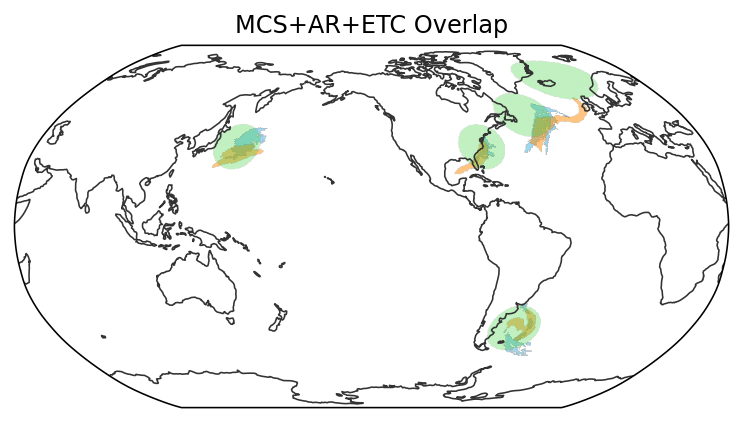

In [29]:
# Create a new mask array with only MCS tracks that have significant AR+ETC overlap
mcs_ar_etc_overlap_mask = xr.where(
    _ds.mcs_mask.isin(mcs_tracks_with_ar_etc_overlap), 
    _ds.mcs_mask, 
    0
)
# Display info about the new mask
print(f"Tracks in overlap mask: {np.unique(mcs_ar_etc_overlap_mask)[np.unique(mcs_ar_etc_overlap_mask) > 0]}")

# Create a new mask array with only AR tracks that have significant MCS+ETC overlap
ar_mcs_etc_overlap_mask = xr.where(
    _ds.ar_mask.isin(ar_tracks_with_mcs_etc_overlap), 
    _ds.ar_mask, 
    0
)
print(f"AR tracks in overlap mask: {np.unique(ar_mcs_etc_overlap_mask)[np.unique(ar_mcs_etc_overlap_mask) > 0]}")

# Create a new mask with only ETC tracks that have significant MCS+AR overlap
etc_mcs_ar_overlap_mask = xr.where(
    _ds.etc_mask.isin(etc_tracks_with_mcs_ar_overlap), 
    _ds.etc_mask, 
    0
)
print(f"ETC tracks in overlap mask: {np.unique(etc_mcs_ar_overlap_mask)[np.unique(etc_mcs_ar_overlap_mask) > 0]}")

# Visualize the new mask
im_mcs = egh.healpix_show(
    mcs_ar_etc_overlap_mask.where(mcs_ar_etc_overlap_mask > 0), 
    # cmap=cmaps.cet_g_bw_minc_minl, 
    cmap=mpl.colors.ListedColormap('skyblue'),
    dpi=144, 
    alpha=0.8
)
im_ar = egh.healpix_show(
    ar_mcs_etc_overlap_mask.where(ar_mcs_etc_overlap_mask > 0), 
    cmap=mpl.colors.ListedColormap('darkorange'), 
    dpi=144, 
    alpha=0.5
)
im_etc = egh.healpix_show(
    etc_mcs_ar_overlap_mask.where(etc_mcs_ar_overlap_mask > 0),
    cmap=mpl.colors.ListedColormap('limegreen'),
    dpi=144,
    alpha=0.3
)
plt.title(f"MCS+AR+ETC Overlap")
# plt.title(f"MCS+AR+ETC Overlap\n{len(mcs_tracks_with_ar_overlap)} tracks shown")
plt.show()

In [10]:
# # Loop to create plots for a date range
# start_date = '2019-11-24T00'
# end_date = '2019-11-24T04'

# # Create date range
# time_range = pd.date_range(start=start_date, end=end_date, freq='3H')

# # Set up consistent styling for all plots
# custom_colors = {
#     'mcs': 'lightskyblue',
#     'ar': 'darkorange', 
#     'etc': 'limegreen',
#     'tc': 'crimson'
# }

# custom_alphas = {
#     'mcs': 0.8,    
#     'ar': 0.5,     
#     'etc': 0.3,    
#     'tc': 0.6      
# }

# title_fontsize = 18
# legend_fontsize = 12
# figsize = (12, 6.75)
# dpi = 200

# print(f"Creating plots from {start_date} to {end_date}")
# print(f"Total time steps: {len(time_range)}")

# # Loop through each time step
# for i, time_step in enumerate(time_range):
#     try:
#         # Convert to string format for selection
#         tm_str = time_step.strftime('%Y-%m-%dT%H')
        
#         # Select single time step
#         _ds = ds.sel(time=tm_str, method='nearest')
#         _time = ds.time.sel(time=tm_str, method='nearest')
        
#         # Format time for title and filename
#         time_label = _time.dt.strftime('%Y-%m-%d %H:%M UTC').item()
#         time_str = _time.dt.strftime('%Y%m%d_%H%M').item()
#         title_with_time = f"{source_name.upper()} {time_label}"
#         figname = f'{figdir}{source_name}_allmasks_{time_str}.png'
        
#         # Create plot
#         fig, ax = plot_all_feature_masks(
#             _ds, 
#             title=title_with_time, 
#             figsize=figsize,
#             colors=custom_colors,
#             alphas=custom_alphas,
#             title_fontsize=title_fontsize,
#             legend_fontsize=legend_fontsize,
#             figname=figname,
#             dpi=dpi
#         )
        
#         # Close figure to save memory
#         plt.close(fig)
        
#         # Progress update
#         if (i + 1) % 10 == 0 or i == len(time_range) - 1:
#             print(f"Completed {i + 1}/{len(time_range)} plots")
            
#     except Exception as e:
#         print(f"Error processing time {tm_str}: {e}")
#         continue

# print("Finished creating all plots!")